<a href="https://colab.research.google.com/github/Rarora18/Backend/blob/main/House_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/kaggle/housing.csv")

In [70]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [72]:
#Data cleaning: Removes 207 ros where total_bedrooms is missing. Simple and effective for this dataset
data.dropna(inplace = True)

In [73]:
#Train test split - 80/20 split
from sklearn.model_selection import train_test_split

x = data.drop("median_house_value", axis = 1)
y = data["median_house_value"]



In [74]:
#Temporarily rejoin X and y for easier preprocessing and visualization
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)


In [75]:
train_data = X_train.join(y_train)

In [76]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
15037,-116.98,32.77,29.0,3558.0,447.0,1097.0,445.0,8.0930,<1H OCEAN,379600.0
9492,-123.20,39.23,26.0,786.0,168.0,494.0,161.0,2.3583,<1H OCEAN,105400.0
13737,-117.21,34.04,14.0,3063.0,426.0,1570.0,419.0,6.2917,INLAND,224700.0
3327,-122.83,38.89,11.0,640.0,134.0,268.0,90.0,3.4514,<1H OCEAN,100000.0
20507,-121.52,38.59,35.0,6418.0,1545.0,3814.0,1496.0,1.6647,INLAND,69100.0
...,...,...,...,...,...,...,...,...,...,...
15093,-116.95,32.82,19.0,5308.0,1058.0,2852.0,1092.0,2.9161,<1H OCEAN,135700.0
2149,-119.77,36.77,29.0,2554.0,705.0,2669.0,655.0,1.2176,INLAND,61900.0
5326,-118.45,34.05,28.0,801.0,399.0,936.0,406.0,2.1875,<1H OCEAN,181300.0
14411,-117.23,32.79,28.0,2453.0,648.0,1082.0,617.0,3.6250,NEAR OCEAN,266700.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

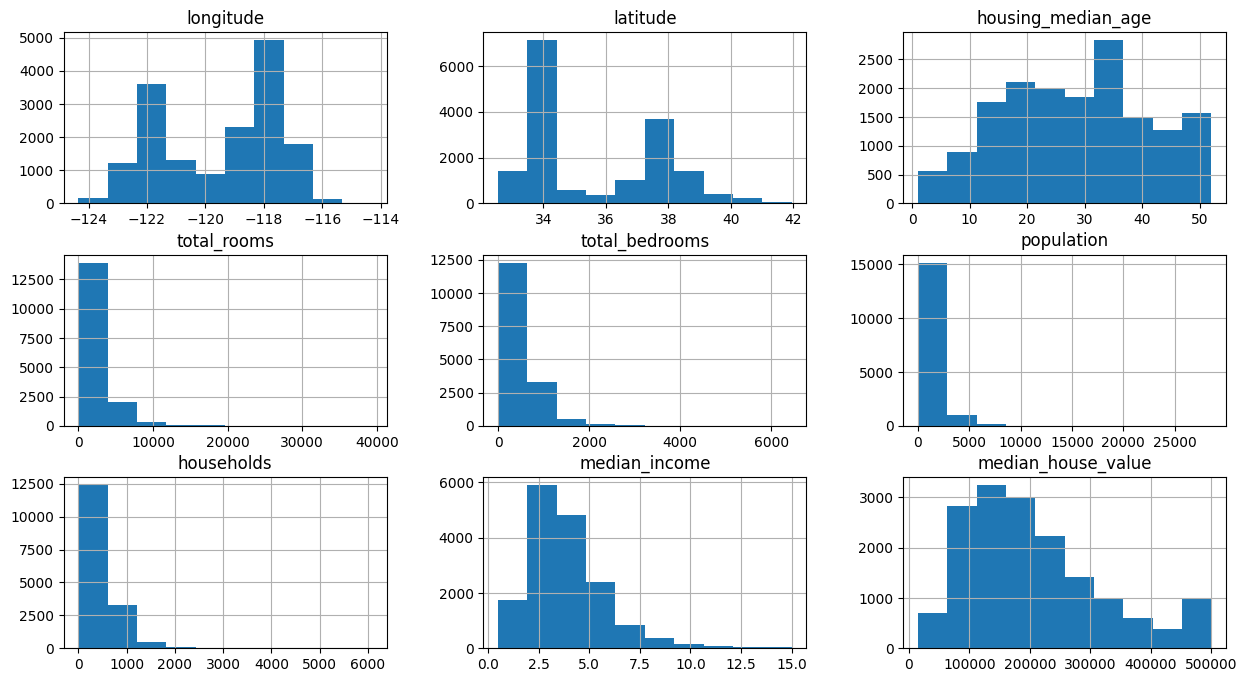

In [77]:
#Visualize Distribu#This plots a histogram for every column.
#You'll notice that total_rooms, total_bedrooms, population, and
#households are all heavily right-skewed (long tail to the right).
#This is bad for linear models, so we fix it next.
train_data.hist(figsize = (15,8))

In [78]:
#Applied np.log(x+1) to skewed features to compress large values
# and spread out small ones: total rooms. total_bedrooms, population, households

train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

In [79]:
# One-hot encode the categorical column:
#Machine learning models only understand numbers. ocean_proximity has 5 text categories
#(INLAND, NEAR BAY, etc.), so pd.get_dummies converts each into its own binary column (0 or 1). #Then we drop the original text column.
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity']))
train_data = train_data.drop(['ocean_proximity'], axis=1)
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
15037,-116.98,32.77,29.0,8.177235,6.104793,7.001246,6.100319,8.0930,379600.0,True,False,False,False,False
9492,-123.20,39.23,26.0,6.668228,5.129899,6.204558,5.087596,2.3583,105400.0,True,False,False,False,False
13737,-117.21,34.04,14.0,8.027477,6.056784,7.359468,6.040255,6.2917,224700.0,False,True,False,False,False
3327,-122.83,38.89,11.0,6.463029,4.905275,5.594711,4.510860,3.4514,100000.0,True,False,False,False,False
20507,-121.52,38.59,35.0,8.767018,7.343426,8.246696,7.311218,1.6647,69100.0,False,True,False,False,False


<Axes: >

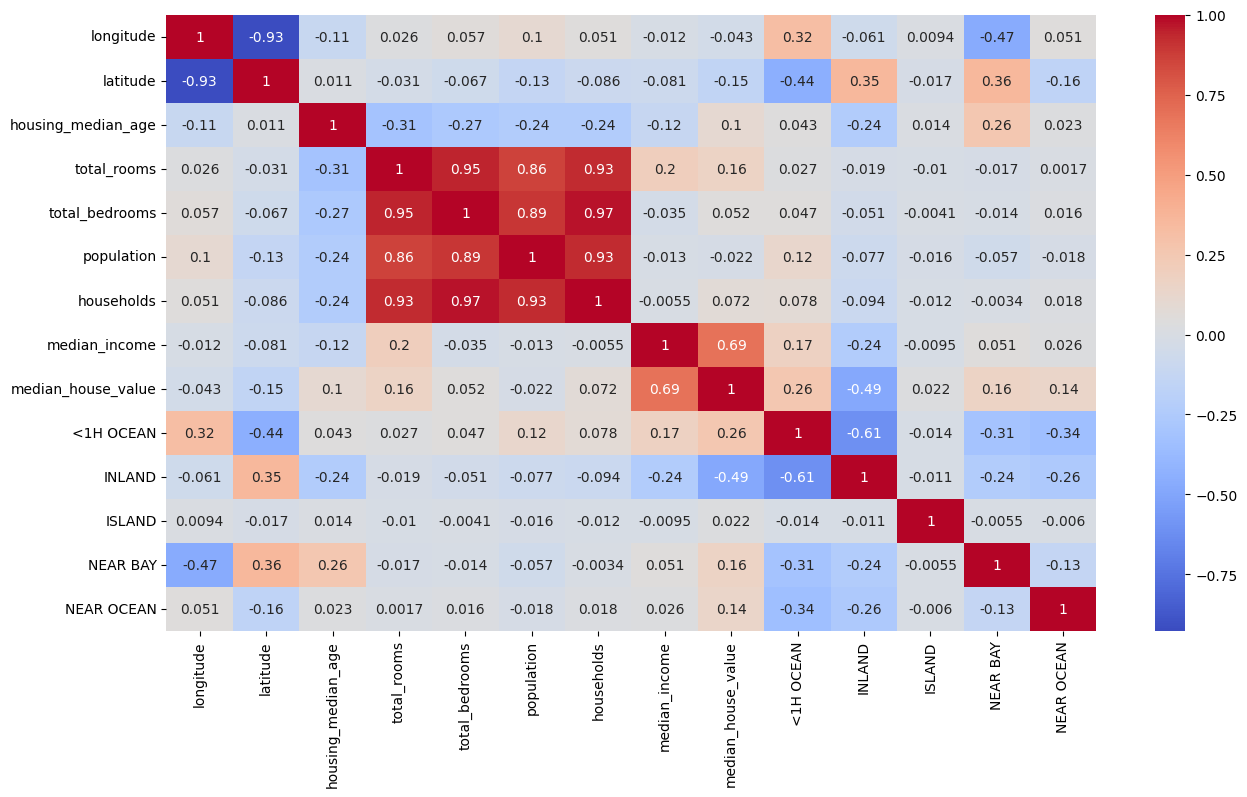

In [80]:
#Correlation heatmap: Shows how strongly each feature correlates with median_house_value. median_income
#has the highest correlation (~0.68)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm')



In [81]:
#Feature Engineering: Create 2 new features that are more meaningful than raw counts:
#1. bedroom_ratio (fraction of rooms that are bedrooms)
#2. household_ratio(avg rooms per household (higher = bigger homes))
train_data['bedroom_ratio']    = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms']  = train_data['total_rooms'] / train_data['households']

In [82]:
#Prepare final training & Test sets
X_train = train_data.drop('median_house_value', axis=1)
y_train = train_data['median_house_value']

  #Apply the exact same transformations to test data
test_data = X_test.join(y_test)
test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data['ocean_proximity']))
test_data = test_data.drop(['ocean_proximity'], axis=1)

for col in X_train.columns:
    if col not in test_data.columns:
        test_data[col] = 0
test_data = test_data.reindex(columns=X_train.columns.tolist() + ['median_house_value'])


test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

X_test_final = test_data.drop('median_house_value', axis=1)
y_test_final = test_data['median_house_value']










In [83]:
#Linear Regression

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)
print("Linear Regression Score:", reg.score(X_test_final, y_test_final))


Linear Regression Score: 0.6775834182695663


In [85]:
#Random Forest Algorithm:

from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(X_train, y_train)
print("Random Forest Score:", forest.score(X_test_final, y_test_final))

Random Forest Score: 0.8236299124126525


In [87]:
# A sample house — you can change these values
sample = {
    'longitude':           -122.23,
    'latitude':             37.88,
    'housing_median_age':   41.0,
    'total_rooms':          np.log(880 + 1),      # remember to log transform!
    'total_bedrooms':       np.log(129 + 1),
    'population':           np.log(322 + 1),
    'households':           np.log(126 + 1),
    'median_income':        8.3252,
    '<1H OCEAN':            0,
    'INLAND':               0,
    'ISLAND':               0,
    'NEAR BAY':             1,                    # set the correct location to 1
    'NEAR OCEAN':           0,
    'bedroom_ratio':        np.log(129+1) / np.log(880+1),
    'household_rooms':      np.log(880+1) / np.log(126+1),
}

sample_df = pd.DataFrame([sample])
sample_df = sample_df.reindex(columns=X_train.columns)  # match column order

prediction = best_forest.predict(sample_df)
print(f"Predicted House Price: ${prediction[0]:,.2f}")

Predicted House Price: $437,660.14
